In [30]:
include("EllipsoidFragmentation.jl")
include("ProjectionMapper.jl")
include("SimulationIO.jl")

import .EllipsoidFragmentation
import .ProjectionMapper
import .SimulationIO

import Plots
import DataFrames
import Statistics

In [31]:
import Plots

function show_sample(child, plots)
    pxy, pxz, pyz = plots
    P = EllipsoidFragmentation.sample_points_child(child; sampling=1000)
    X = P[1, :]
    Y = P[2, :]
    Z = P[3, :]

    Plots.scatter!(pxy, X, Y)
    Plots.scatter!(pxz, X, Z)
    Plots.scatter!(pyz, Y, Z)
end

function plot_projections(projections, childs; npoints::Int=200, equal_aspect::Bool=true, sampling::Bool=false)
    function ellipse_points(xc, yc, a, b, θ; n=npoints)
        t = range(0, 2π; length=n)
        ct, st = cos(θ), sin(θ)
        x = xc .+ a .* cos.(t) .* ct .- b .* sin.(t) .* st
        y = yc .+ a .* cos.(t) .* st .+ b .* sin.(t) .* ct
        return x, y
    end

    pxy = Plots.plot(title="XY", xlabel="x", ylabel="y", legend=false)
    pxz = Plots.plot(title="XZ", xlabel="x", ylabel="z", legend=false)
    pyz = Plots.plot(title="YZ", xlabel="y", ylabel="z", legend=false)

    for (axis, p) in ((:xy, pxy), (:xz, pxz), (:yz, pyz))
        for (xc, yc, sa, sb, ang, l) in projections[axis]
            x, y = ellipse_points(xc, yc, sa, sb, ang)
            Plots.plot!(p, x, y)
        end
        if equal_aspect
            Plots.plot!(p, aspect_ratio=:equal)
        end
    end

    if sampling
        for child in childs
            show_sample(child, [pxy, pxz, pyz])
        end
    end

    return Plots.plot(pxy, pxz, pyz; layout=(1, 3), size=(1200, 400))
end

plot_projections (generic function with 1 method)

In [32]:
# Charger configuration
config = SimulationIO.load_config("config.toml")

# Créer population
parents = SimulationIO.create_initial_parents(config; seed=42)
gen = SimulationIO.create_generator(config, parents)

# Générer
ellipsoids = EllipsoidFragmentation.build_population!(gen; verbose=true)

println("Nombre total d'ellipsoïdes: ", length(ellipsoids))

Building level 1 with 10 parents...
  Created 12 children
Building level 2 with 12 parents...
  Created 12 children
Building level 3 with 12 parents...
  Created 14 children
Building level 4 with 14 parents...


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


  Created 17 children
Building level 5 with 17 parents...


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


  Created 19 children
Nombre total d'ellipsoïdes: 84


# Visualiser les projections

Projecting ellipsoids... 100%|███████████████████████████| Time: 0:00:00


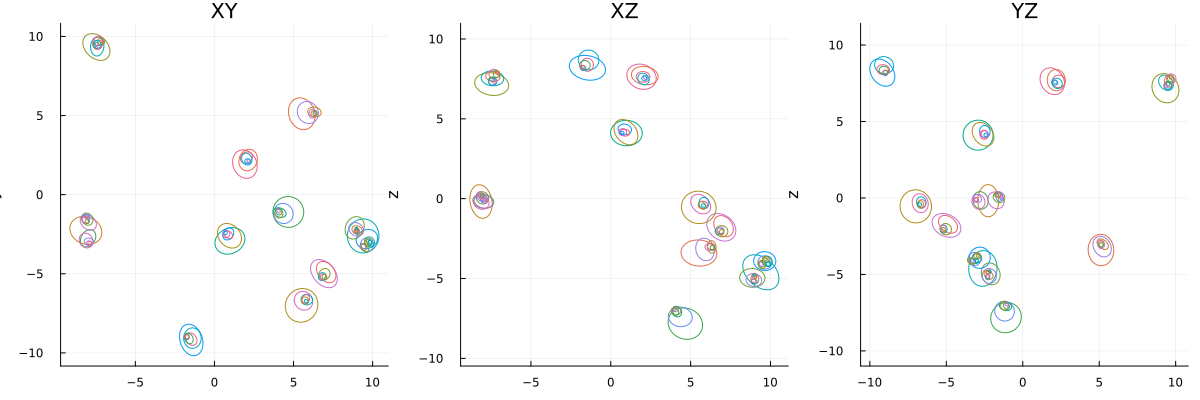

In [33]:
projector = ProjectionMapper.Projector(ellipsoids)
projections = ProjectionMapper.project_population(projector)

fig = plot_projections(projections, ellipsoids)
Plots.display(fig)  

# Incertitudes

In [34]:
# Charger configuration
config = SimulationIO.load_config("config.toml")
parents = SimulationIO.create_initial_parents(config; seed=42)

# Tester différents taux de fragmentation
frag_rates = [0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 2.5, 3.0]
scaling_ratios = SimulationIO.set_scaling_ratios(config)
println(scaling_ratios)

errors = Float64[]
phi2d = Float64[]

for phi in frag_rates
    parents_test = deepcopy(parents)
    gen_test = EllipsoidFragmentation.Generator(parents_test, 
                        fill(phi, length(scaling_ratios)),
                        scaling_ratios,
                        0.9, 1e-3, 10000)
    
    ells = EllipsoidFragmentation.build_population!(gen_test; verbose=false)
    proj_test = ProjectionMapper.Projector(ells)
    projections_test = ProjectionMapper.project_population(proj_test)
    
    # Calculer erreur
    counts_3d, counts_2d = ProjectionMapper.count_by_level(proj_test.data, projections_test)

    println(counts_2d)
    max_ratio = prod(scaling_ratios)
    println(max_ratio)
    phi_mes2d = - (log( counts_2d[:xy][0]) - log( counts_2d[:xy][length(scaling_ratios)])) / log(max_ratio)
    push!(phi2d, phi_mes2d)
    
    println("φ = $phi, φ2D = $phi_mes2d")
end

[1.5, 1.5, 1.5, 1.5, 1.5]


Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:05
Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04


Dict(:yz => Dict(0 => 10, 4 => 13, 5 => 13, 2 => 13, 3 => 13, 1 => 12), :xy => Dict(0 => 10, 4 => 13, 5 => 13, 2 => 13, 3 => 13, 1 => 12), :xz => Dict(0 => 10, 4 => 13, 5 => 13, 2 => 13, 3 => 13, 1 => 12))
7.59375
φ = 0.4, φ2D = 0.1294139787720037


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
Progress: 100%|█████████████████████████████████████████| Time: 0:00:02
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04
Progress: 100%|█████████████████████████████████████████| Time: 0:00:04


Dict(:yz => Dict(0 => 10, 4 => 19, 5 => 21, 2 => 13, 3 => 15, 1 => 12), :xy => Dict(0 => 10, 4 => 19, 5 => 21, 2 => 13, 3 => 15, 1 => 12), :xz => Dict(0 => 10, 4 => 19, 5 => 21, 2 => 13, 3 => 15, 1 => 12))
7.59375
φ = 0.6, φ2D = 0.36596852843448785


...

Dict(:yz => Dict(0 => 10, 4 => 27, 5 => 35, 2 => 19, 3 => 22, 1 => 15), :xy => Dict(0 => 10, 4 => 27, 5 => 35, 2 => 19, 3 => 22, 1 => 15), :xz => Dict(0 => 10, 4 => 27, 5 => 35, 2 => 19, 3 => 22, 1 => 15))
7.59375
φ = 2.0, φ2D = 0.6179387293474204


Progress: 100%|█████████████████████████████████████████| Time: 0:00:09
Progress: 100%|█████████████████████████████████████████| Time: 0:00:14
Progress: 100%|█████████████████████████████████████████| Time: 0:00:22
Progress: 100%|█████████████████████████████████████████| Time: 0:00:25
Progress: 100%|█████████████████████████████████████████| Time: 0:00:36


Dict(:yz => Dict(0 => 10, 4 => 33, 5 => 37, 2 => 19, 3 => 24, 1 => 15), :xy => Dict(0 => 10, 4 => 33, 5 => 37, 2 => 19, 3 => 24, 1 => 15), :xz => Dict(0 => 10, 4 => 33, 5 => 37, 2 => 19, 3 => 24, 1 => 15))
7.59375
φ = 2.5, φ2D = 0.645349152608791


Progress: 100%|█████████████████████████████████████████| Time: 0:00:11
Progress: 100%|█████████████████████████████████████████| Time: 0:00:14
Progress: 100%|█████████████████████████████████████████| Time: 0:00:21
Progress: 100%|█████████████████████████████████████████| Time: 0:00:29
Progress: 100%|█████████████████████████████████████████| Time: 0:00:36


Dict(:yz => Dict(0 => 10, 4 => 33, 5 => 39, 2 => 20, 3 => 26, 1 => 14), :xy => Dict(0 => 10, 4 => 33, 5 => 39, 2 => 20, 3 => 26, 1 => 14), :xz => Dict(0 => 10, 4 => 33, 5 => 39, 2 => 20, 3 => 26, 1 => 14))
7.59375
φ = 3.0, φ2D = 0.6713162370422947


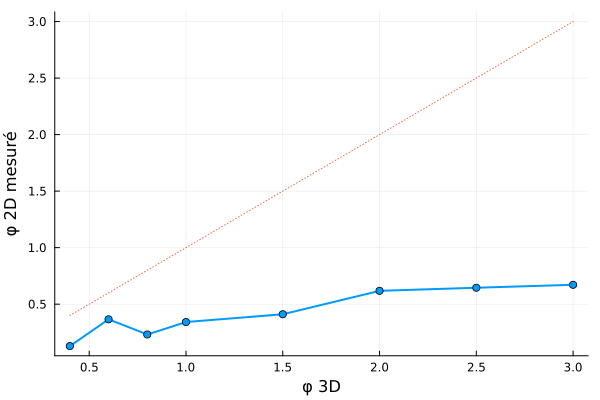

In [35]:
Plots.plot(frag_rates, phi2d,
    xlabel="φ 3D",
    ylabel="φ 2D mesuré",
    marker=:circle,
    linewidth=2,
    legend=false)

Plots.plot!(frag_rates, frag_rates,
    linestyle = :dot,
    legend=false)

# Synthetic column density map

In [36]:
function make_linear_grid(xmin, xmax, ymin, ymax, Nx, Ny)
    xs = range(xmin, xmax, length=Nx)
    ys = range(ymin, ymax, length=Ny)

    delta_x = Nx > 1 ? (xmax - xmin) / (Nx - 1) : 1.0
    delta_y = Ny > 1 ? (ymax - ymin) / (Ny - 1) : 1.0

    offset_x = xmin   # centre du pixel i=1
    offset_y = ymin   # centre du pixel j=1

    return xs, ys, delta_x, delta_y, offset_x, offset_y
end

function bounding_box_from_ellipses(proj; nsig=4.0)
    xmin = +Inf
    xmax = -Inf
    ymin = +Inf
    ymax = -Inf

    for (xc, yc, sa, sb, ang) in proj
        hx = nsig * sqrt((sa*cos(ang))^2 + (sb*sin(ang))^2)
        hy = nsig * sqrt((sa*sin(ang))^2 + (sb*cos(ang))^2)

        xmin = min(xmin, xc - hx)
        xmax = max(xmax, xc + hx)
        ymin = min(ymin, yc - hy)
        ymax = max(ymax, yc + hy)
    end

    return xmin, xmax, ymin, ymax
end

function add_ellipse_gaussian!(M, xs, ys, xc, yc, sa, sb, ang; A=10.0)
    Ny, Nx = size(M)
    c = cos(ang)
    s = sin(ang)

    @assert length(xs) == Nx
    @assert length(ys) == Ny

    for j in 1:Ny
        y = ys[j]
        for i in 1:Nx
            x = xs[i]

            dx = x - xc
            dy = y - yc

            xr =  c*dx + s*dy
            yr = -s*dx + c*dy

            M[j, i] += A * exp(-0.5 * ((xr/sa)^2 + (yr/sb)^2))
        end
    end
end

xmin, xmax, ymin, ymax = bounding_box_from_ellipses(projections[:xy], nsig=4.0)

Nx = 256
Ny = 256

xs, ys, delta_x, delta_y, offset_x, offset_y = make_linear_grid(xmin, xmax, ymin, ymax, Nx, Ny)

CRPIX1 = 1.0
CRPIX2 = 1.0
CRVAL1 = offset_x
CRVAL2 = offset_y
CDELT1 = delta_x
CDELT2 = delta_y

M = zeros(Float64, Ny, Nx)

for (xc, yc, sa, sb, ang, l) in projections[:xy]
    add_ellipse_gaussian!(M, xs, ys, xc, yc, sa, sb, ang; A=10.0)
end

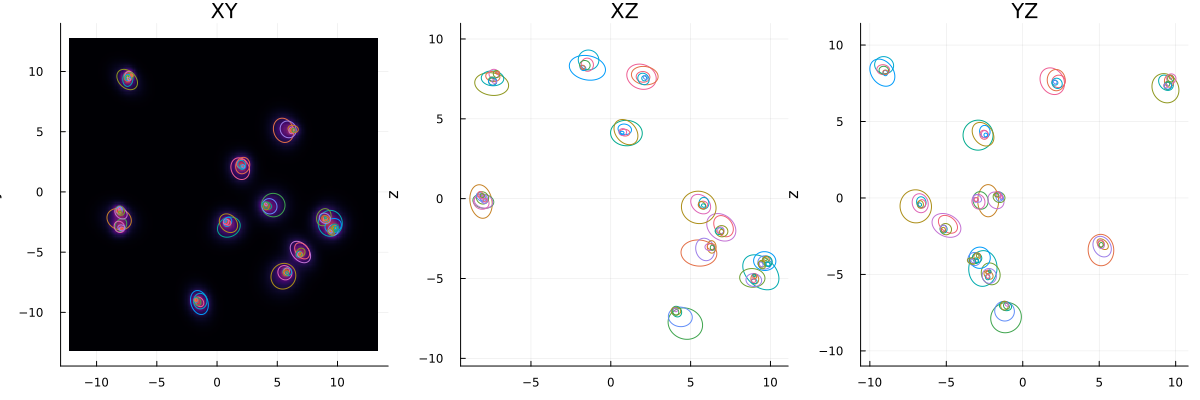

In [37]:
fig = plot_projections(projections, ellipsoids)
Plots.heatmap!(fig, xs, ys, M; z_order=:back, aspect_ratio=:equal)

Plots.display(fig) 


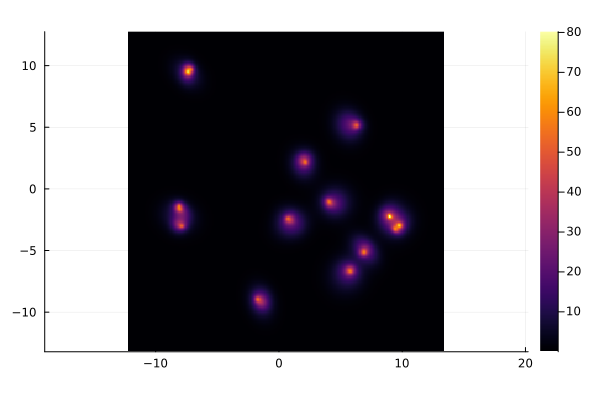

In [38]:
Plots.heatmap(xs, ys, M; z_order=:back, aspect_ratio=:equal)

# Save as .fits

In [39]:
using FITSIO

function write_gaussian_map_fits(filename, M, xs, ys;
                                 ctype1="X",
                                 ctype2="Y",
                                 cunit1="",
                                 cunit2="",
                                 bunit="arb")
    Ny, Nx = size(M)

    delta_x = length(xs) > 1 ? xs[2] - xs[1] : 1.0
    delta_y = length(ys) > 1 ? ys[2] - ys[1] : 1.0
    offset_x = xs[1]
    offset_y = ys[1]

    # Important : on écrit (x,y) dans le FITS
    Mf = permutedims(M, (2, 1))  # taille (Nx, Ny)

    FITS(filename, "w") do f
        write(f, Mf)
        hdu = f[1]

        write_key(hdu, "CTYPE1", ctype1, "Physical axis 1")
        write_key(hdu, "CTYPE2", ctype2, "Physical axis 2")

        if !isempty(cunit1)
            write_key(hdu, "CUNIT1", cunit1, "Unit of axis 1")
        end
        if !isempty(cunit2)
            write_key(hdu, "CUNIT2", cunit2, "Unit of axis 2")
        end

        write_key(hdu, "CRPIX1", 1.0, "Reference pixel axis 1 (FITS, 1-based)")
        write_key(hdu, "CRPIX2", 1.0, "Reference pixel axis 2 (FITS, 1-based)")
        write_key(hdu, "CRVAL1", offset_x, "World coord at reference pixel axis 1")
        write_key(hdu, "CRVAL2", offset_y, "World coord at reference pixel axis 2")
        write_key(hdu, "CDELT1", delta_x, "Pixel scale axis 1")
        write_key(hdu, "CDELT2", delta_y, "Pixel scale axis 2")
        write_key(hdu, "BUNIT",  bunit,   "Data unit")
    end
end

write_gaussian_map_fits (generic function with 1 method)

In [40]:
write_gaussian_map_fits(
    "gaussian_map.fits",
    M, xs, ys;
    ctype1="X",
    ctype2="Y",
    cunit1="mm",
    cunit2="mm",
    bunit="arb"
)

# Save the ellipses data

In [50]:
using CSV
using DataFrames

const SIGMA_TO_FWHM = 2 * sqrt(2 * log(2))


function save_ellipses_csv_by_level(projection, levels;
                                    outdir=".",
                                    angle_unit=:rad,
                                    angle_ref="+X axis, counterclockwise")
    mkpath(outdir)

    for level in 1:levels
        df = DataFrame(
            Xpos   = Float64[],
            Ypos   = Float64[],
            A_FWHM = Float64[],
            B_FWHM = Float64[],
            ANG    = Float64[],
        )

        for (xc, yc, sa, sb, ang, l) in projection
            if level == l
                ang_out = angle_unit == :deg ? rad2deg(ang) : ang

                push!(df, (
                    xc,
                    yc,
                    SIGMA_TO_FWHM * sa,
                    SIGMA_TO_FWHM * sb,
                    ang_out
                ))
            end
        end

        filename = joinpath(outdir, "ellipses_level_$(level).csv")

        open(filename, "w") do io
            println(io, "# Xpos, Ypos: ad-hoc coordinates")
            println(io, "# A_FWHM, B_FWHM: full width at half maximum")
            println(io, "# ANG: angle measured from $(angle_ref)")
            println(io, "# ANG_UNIT: $(angle_unit)")
            CSV.write(io, df; append=true, writeheader=true)
        end
    end
end

save_ellipses_csv_by_level (generic function with 1 method)

In [51]:
save_ellipses_csv_by_level(
    projections[:xy],
    config.n_levels;
    outdir="csv_ellipses",
    angle_unit=:deg,
    angle_ref="+X axis, counterclockwise"
)

In [46]:
config.n_levels

5

In [ ]:
function main()
    input_file = ARGS[1]
    fits_out   = ARGS[2]
    csv_outdir = ARGS[3]
    nxy        = parse(Int, ARGS[4])

    # À adapter à ton format d'entrée
    # ex: projection = load_projection(input_file)
    # levels = 1:nlevels

    # Exemple :
    # M, xs, ys, wcs = build_map_and_save_fits(
    #     ellipses_by_level,
    #     nxy, nxy,
    #     fits_out;
    #     csv_outdir=csv_outdir
    # )

    println("Export terminé")
    println("FITS: " * fits_out)
    println("CSV dir: " * csv_outdir)
end

main()